In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/brendan45774/test-file/tested.csv


In [2]:
import sklearn
print(sklearn)
print(sklearn.__file__)

<module 'sklearn' from '/usr/local/lib/python3.12/dist-packages/sklearn/__init__.py'>
/usr/local/lib/python3.12/dist-packages/sklearn/__init__.py


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import KBinsDiscretizer



In [4]:
df = pd.read_csv('/kaggle/input/datasets/brendan45774/test-file/tested.csv',usecols=['Age','Fare','Survived'])
df

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875
3,0,27.0,8.6625
4,1,22.0,12.2875
...,...,...,...
413,0,NaN,8.0500
414,1,39.0,108.9000
415,0,38.5,7.2500
416,0,NaN,8.0500


In [5]:
df.head()

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875
3,0,27.0,8.6625
4,1,22.0,12.2875


In [6]:
df.dropna(inplace=True)

In [7]:
df.shape

(331, 3)

In [8]:
df.head()

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875
3,0,27.0,8.6625
4,1,22.0,12.2875


In [9]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
X_train.head(2)

,Age,Fare
281,0.75,13.775
96,76.00,78.850


In [12]:
clf = DecisionTreeClassifier()

In [13]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [14]:
accuracy_score(y_test,y_pred)

0.582089552238806

In [15]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.559090909090909)

In [16]:
kbin_age =  KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')
kbin_fare =  KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')

In [17]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [18]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [19]:
trf.named_transformers_['second'].n_bins

10

In [20]:
trf.named_transformers_['second'].bin_edges_

array([array([  0.    ,   7.75  ,   7.8958,  10.5   ,  13.    ,  16.    ,
               26.    ,  31.5   ,  58.41  ,  92.45  , 512.3292])         ],
      dtype=object)

In [21]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [22]:
output['age_labels']= pd.cut(x=X_train['Age'],
                            bins=trf.named_transformers_['first'].bin_edges_[0])

In [23]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels
314,55.0,9.0,135.6333,9.0,"(50.0, 76.0]"
125,17.0,1.0,16.1000,5.0,"(0.33, 17.0]"
115,18.0,1.0,14.4542,4.0,"(17.0, 20.0]"
224,53.0,9.0,27.4458,6.0,"(50.0, 76.0]"
67,47.0,8.0,42.4000,7.0,"(43.8, 50.0]"


In [24]:
from sklearn.tree import DecisionTreeClassifier

#  Model create karo
clf = DecisionTreeClassifier()

#  Model train karo (IMPORTANT STEP)
clf.fit(X_train_trf, y_train)

#  Prediction karo
y_pred2 = clf.predict(X_test_trf)

print(y_pred2)

[0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0 0 0 0 0 0 0 1 1 1 0 1 1 0 0 0 0 0
 0 0 1 0 1 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1]


In [25]:
accuracy_score(y_test,y_pred2)

0.5223880597014925

In [26]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score( DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.5741532976827095)

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

def discretize(bins, strategy):
    
    kbin_age = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
    
    trf = ColumnTransformer([
        ('age', kbin_age, ['Age']),
        ('fare', kbin_fare, ['Fare'])
    ])
    
    X_trf = trf.fit_transform(X)
    
    print("Accuracy:", np.mean(
        cross_val_score(DecisionTreeClassifier(), X_trf, y, cv=10, scoring='accuracy')
    ))
    
    plt.figure(figsize=(14,4))
    
    # Before Discretization
    plt.subplot(121)
    plt.hist(X['Age'], bins=20)
    plt.title("Before Discretization (Age)")
    
    # After Discretization
    plt.subplot(122)
    plt.hist(X_trf[:,0], color='red')
    plt.title("After Discretization (Age)")
    
    plt.show()

Accuracy: 0.5590909090909092


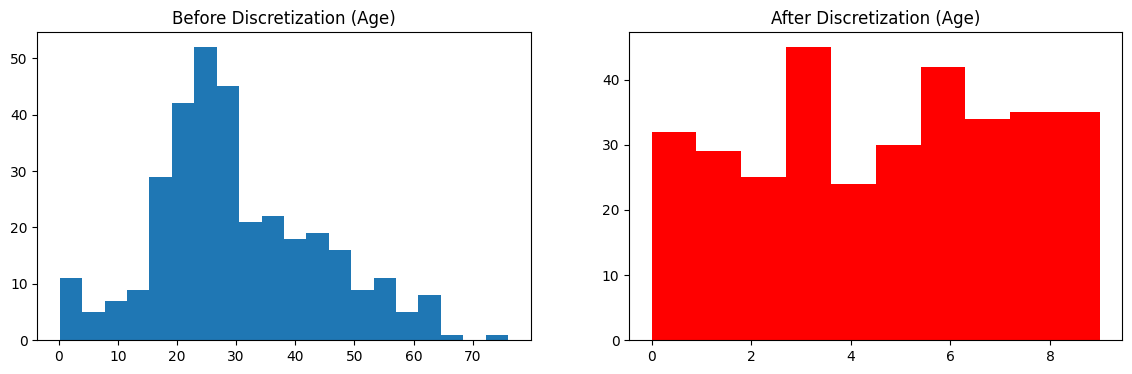

In [28]:
discretize(10, 'quantile')

Accuracy: 0.5923351158645277


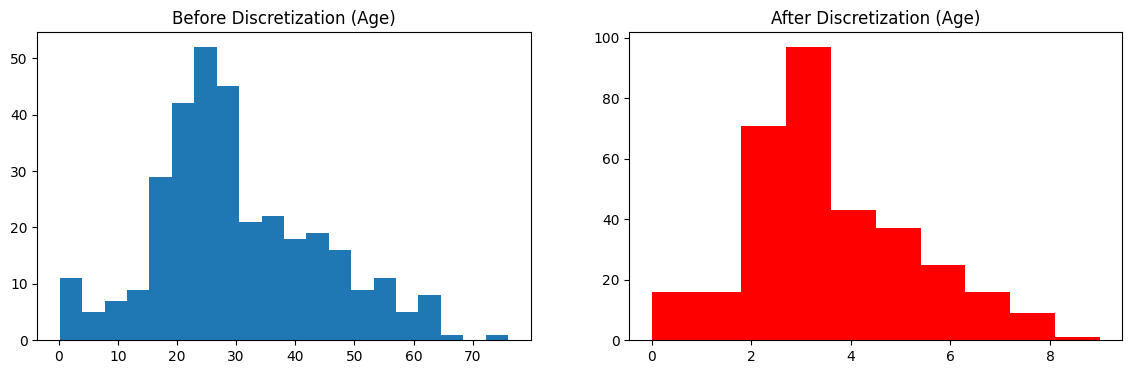

In [29]:
discretize(10, 'uniform')

Accuracy: 0.6014260249554367


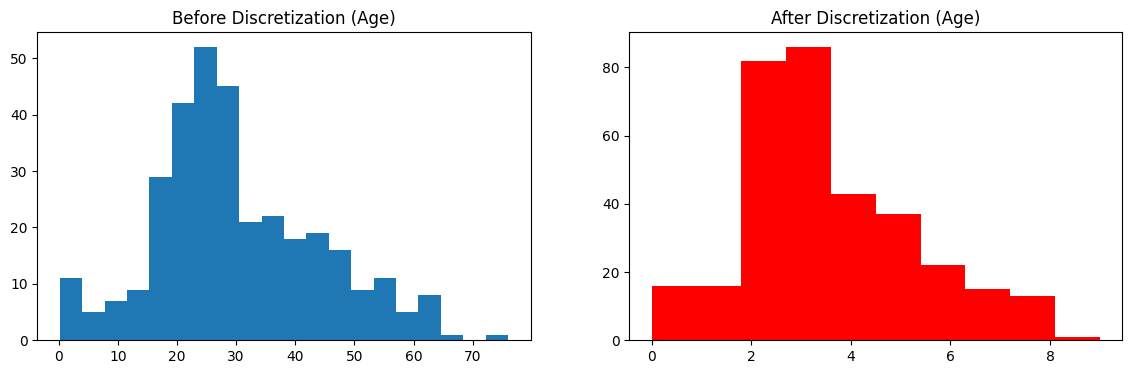

In [30]:
discretize(10, 'kmeans')

In [31]:
 from sklearn.preprocessing import Binarizer 

In [32]:
print(X_train.columns)

Index(['Age', 'Fare'], dtype='object')


In [33]:
trf = ColumnTransformer([
    ('bin',Binarizer(copy=False),['Fare'])
],remainder='passthrough')

In [34]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)


In [35]:
pd.DataFrame(X_train_trf,columns=['fare','Age'])

,fare,Age
0,1.0,0.75
1,1.0,76.00
2,1.0,32.00
3,1.0,27.00
4,1.0,22.00
...,...,...
259,1.0,20.00
260,1.0,27.00
261,1.0,43.00
262,1.0,16.00
